### **Quiz 4 - Time Series**

Nombre:

---
#### **Problema**

**ShopEase** quiere saber cuántas ventas puede esperar en los próximos 12 meses para planificar su inventario y campañas de marketing.

Utiliza el archivo ecommerce_sales_data.csv que contiene las ventas mensuales de los últimos 5 años.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df = pd.read_csv('./resources/ecommerce_sales_data.csv', parse_dates=['Fecha'])
df.head()

,Fecha,Ventas
0,2020-01-01,215
1,2020-02-01,220
2,2020-03-01,240
3,2020-04-01,250
4,2020-05-01,260


**Punto 1 ()**  
**Gráfica las ventas de los utimos 5 años y contesta lo siguiente:**

* ¿Las ventas muestras algun tipo de tendencia?, en caso de que sí, explica de que tipo es.
Si, las ventas muestran una tendencia creciente a lo largo del tiempo

* ¿Se observa estacionalidad en la serie? ¿Por qué? Si, esto porque probablemente existan fechas en las cuales existe una mayor demanda de productos, como el día de las madres, navidad, etc.

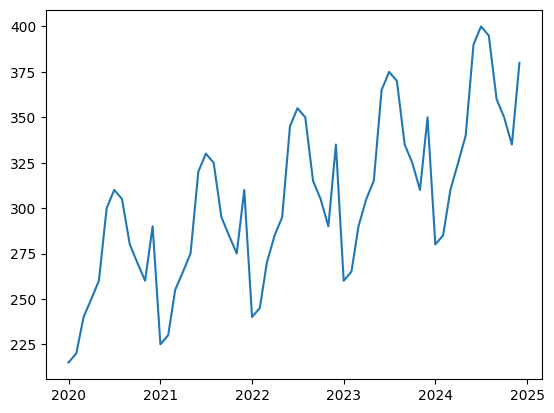

In [18]:
#Code
plt.plot(df['Fecha'], df['Ventas'])


**Punto 2 ()**   
**Crea un modelo de series de tiempo usando la librería `prophet` como lo vimos en clase para predecir las ventas mensuales durante los próximos 12 meses.**

Nota:
* No necesitar separar la base en train / test  
* Recuerda renombrar columnas como exige Prophet: ds = fecha, y = valor

In [7]:
#Code
df.rename({'Fecha':'ds', 'Ventas':'y'},axis=1,inplace=True)

modelo_prophet = Prophet()
modelo_prophet.fit(df)

future = modelo_prophet.make_future_dataframe(periods=12, freq='MS',include_history=False)
future.head()

20:17:27 - cmdstanpy - INFO - Chain [1] start processing
20:17:27 - cmdstanpy - INFO - Chain [1] done processing


,ds
0,2025-01-01
1,2025-02-01
2,2025-03-01
3,2025-04-01
4,2025-05-01


In [8]:
forecast = modelo_prophet.predict(future)

**Punto 3 (20 puntos)**   
**Visualiza en un gráfico las predicciones de ventas para los próximo 12 meses, junto con los datos históricos.**

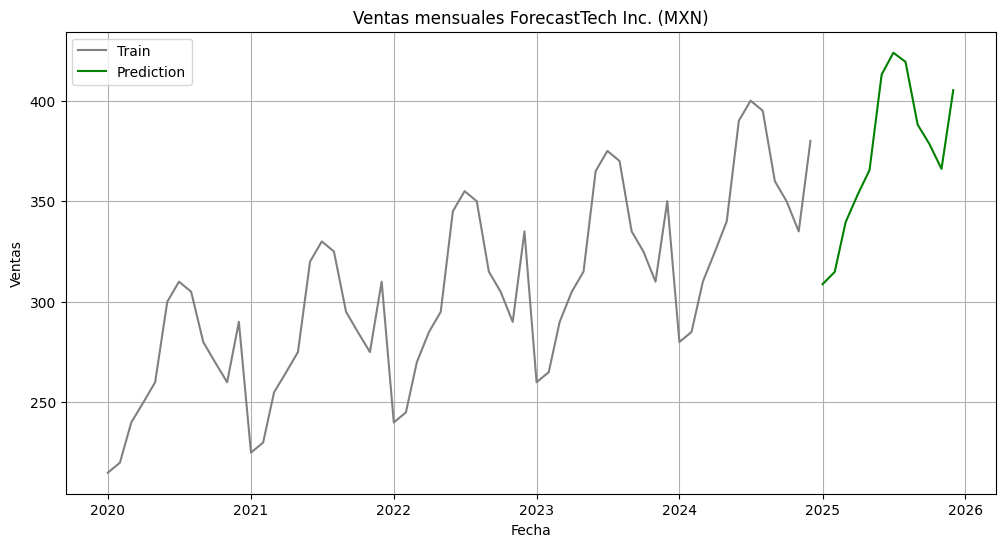

In [10]:
#code
plt.figure(figsize=(12,6))
# Entrenamiento (Train) - Valores reales
plt.plot(df['ds'], df['y'], label='Train', color='gray')
# Prueba (Test) - Valores reales
# Predicción (Forecast) - Línea central
plt.plot(forecast['ds'], forecast['yhat'], label='Prediction', color='green')
# Título y etiquetas
plt.title('Ventas mensuales ForecastTech Inc. (MXN)')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.legend()
plt.grid(True)
plt.show()

**Punto 4 (20 puntos)**  
**¿Cuánto es el total de las ventas esperadas en los próximos 12 meses?**

In [14]:
#code
round(sum(forecast['yhat']))

4476

**Punto 5 (20 puntos)**  
**Explica tus conclusiones sobre el comportamiento esperado de las ventas en el próximo año.**

*Respuesta*

El comportamiento esperado es que las ventas mantengas le estacionalidad que se ha obserdado en los ultimos 5 añios, con un crecimiento proporcional a la tendencia y que además, esta incremente al final del año.